# FINAL PROJECT

**Deliverables**:
  1. Your version of this notebook, where you create the required agents (complete all the associated tasks)

  2. After training your agents, you might want to save those learnt values. This can be a dictionary with the `optimal policy`, or `Q-values`. If an approximate method was used, you can provide the `final weights`, etc.

  3. A short report (no more than 10 pages), where you explain your methodology, chosen parameters, visualisations of the learning process (how rewards increase over time, or how loss functions decrease).

  4. Upload to `Faser` a .zip file of all the deliverables (including th optimal Q-values/weights/policies)

**Evaluation**: Your projects will be evaluated primarily on the development of the agents, not necessarily in their performance. Being said that, better performance will lead in general to better marks.

## 0. Setup

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import gymnasium as gym
from IPython.display import Image, display
import imageio

from collections import defaultdict
from tqdm import tqdm
from optuna.trial import FixedTrial

from src.logger import LogManager
from src.utils import (
    save_policy, load_policy, plot_learning_curve, 
    plot_smoothed_learning_curve, q_stats
)
from src.optimization import param_opt_pipeline, get_params

In [2]:
manager = LogManager()

main_log = manager.get_logger("Main", "main.log")

In [3]:
env = gym.make("Acrobot-v1", render_mode = "rgb_array")
state = env.reset()

main_log.info("--- New Session Started ---")
main_log.info(f"Environment: Acrobot-v1")
main_log.info(f"Initial State: {state}")
main_log.info(f"State Space: {env.observation_space}")
main_log.info(f"Action Space: {env.action_space}")

2026-04-20 21:37:10 | INFO    | --- New Session Started ---
2026-04-20 21:37:10 | INFO    | Environment: Acrobot-v1
2026-04-20 21:37:10 | INFO    | Initial State: (array([ 0.99967206, -0.02560802,  0.9994807 , -0.03222185, -0.0372945 ,
       -0.02756958], dtype=float32), {})
2026-04-20 21:37:10 | INFO    | State Space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
2026-04-20 21:37:10 | INFO    | Action Space: Discrete(3)


[ACROBOT ENVIRONMENT](https://gymnasium.farama.org/environments/classic_control/acrobot/)

Below is the default discretisation (for the states. Actions are already discrete). If you consider that a different one, could lead to better performance, feel free to modify it, and indicate this in your report.

In [4]:
ANGLE_BINS = 10
VEL_BINS = 12

LOW = np.array([-np.pi, -np.pi, -6, -10])
HIGH = np.array([ np.pi,  np.pi,  6,  10])
BINS = np.array([ANGLE_BINS, ANGLE_BINS, VEL_BINS, VEL_BINS])

def transform_state(obs):
    cos1, sin1, cos2, sin2, w1, w2 = obs
    
    theta1 = np.arctan2(sin1, cos1)
    theta2 = np.arctan2(sin2, cos2)
    
    return np.array([theta1, theta2, w1, w2])

def discretise(obs):
    state = transform_state(obs)
    
    ratios = (state - LOW) / (HIGH - LOW)
    ratios = np.clip(ratios, 0, 1)
    
    discrete = (ratios * (BINS - 1)).astype(int)
    return tuple(discrete)

In [5]:
main_log.info(f"Discretization Bins: {BINS}")

2026-04-20 21:37:10 | INFO    | Discretization Bins: [10 10 12 12]


## 1. Notebook Utilities

In [6]:
def select_action(policy, state, mode="greedy", epsilon=0.05, rng=None):
    if rng is None:
        rng = np.random.default_rng()

    values = policy[state]
    n_actions = len(values)

    # Detect policy type by whether values sum to ~1 (probability dist) or not (Q-values)
    is_prob_policy = np.isclose(values.sum(), 1.0)

    if mode == "greedy":
        return int(np.argmax(values))

    elif mode == "stochastic":
        if is_prob_policy:
            return int(rng.choice(n_actions, p=values))
        else:
            # Softmax over Q-values as a fallback
            exp_q = np.exp(values - np.max(values))
            probs = exp_q / exp_q.sum()
            return int(rng.choice(n_actions, p=probs))

    elif mode == "epsilon_greedy":
        if rng.random() < epsilon:
            return int(rng.integers(n_actions))
        return int(np.argmax(values))

In [7]:
def evaluate_policy(policy, n_episodes=20, mode="greedy", seed=42):
    env = gym.make("Acrobot-v1")

    rewards = []
    steps = []

    for ep in range(n_episodes):
        rng = np.random.default_rng(seed + ep)

        obs, _ = env.reset()
        state = discretise(obs)

        done = False
        total_reward = 0
        t = 0

        while not done:
            action = select_action(policy, state, mode = mode, rng = rng)
            obs, reward, term, trunc, _ = env.step(action)

            state = discretise(obs)
            total_reward += reward
            t += 1
            done = term or trunc

        rewards.append(total_reward)
        steps.append(t)

    return {
        "mean_reward": np.mean(rewards),
        "std_reward": np.std(rewards),
        "mean_steps": np.mean(steps),
        "success_rate": np.mean(np.array(steps) < 500)
    }

In [8]:
def record_episode(policy, filename, mode="greedy"):
    env = gym.make("Acrobot-v1", render_mode="rgb_array")
    frames = []

    obs, _ = env.reset()
    state = discretise(obs)

    done = False

    while not done:
        frames.append(env.render())
        action = select_action(policy, state, mode=mode)
        obs, reward, term, trunc, _ = env.step(action)

        state = discretise(obs)
        done = term or trunc

    imageio.mimsave(filename, frames, fps=50)

In [9]:
def run_experiment(algorithm_func, params):
    name = algorithm_func.__name__
    main_log.info(f"Starting Experiment: {name}")
    
    params["seed"] = 42
    params["n_episodes"] = 5000

    if "floor_fraction" in params.keys():
        decay_steps = int(params["floor_fraction"] * params["n_episodes"])
        params["epsilon_decay"] = params["epsilon_min"] ** (1.0 / decay_steps)

    main_log.info(f"Hyperparameters: {params}")

    # ---------------- TRAIN ----------------
    model, rewards = algorithm_func(env, params=params)

    main_log.info(f"{name} Training Completed")

    # ---------------- SAVE ----------------
    save_policy(model, name)

    # ---------------- EVALUATE ----------------
    eval_greedy = evaluate_policy(model, mode="greedy")
    eval_stochastic = evaluate_policy(model, mode="stochastic")

    main_log.info(f"{name} Evaluation (Greedy): {eval_greedy}")

    print("\n=== EVALUATION ===")
    print("Greedy:", eval_greedy)
    print("Stochastic:", eval_stochastic)

    # ---------------- PLOTS ----------------
    plot_learning_curve(rewards, name)
    plot_smoothed_learning_curve(rewards, name)

    # ---------------- RECORD ----------------
    record_episode(model, f"results/{name}_greedy.gif", mode="greedy")
    record_episode(model, f"results/{name}_stochastic.gif", mode="stochastic")

    return model, rewards, {
        "greedy": eval_greedy,
        "stochastic": eval_stochastic
    }

## 2. Algorithms

### SARSA

In [10]:
def alg_SARSA(env, params):
    """
    SARSA implementation.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    for ep in tqdm(range(n_episodes), desc = "Training SARSA"):
        obs, _ = env.reset()
        state = discretise(obs)
        action = select_action(
            policy = Q, 
            state = state, 
            mode = "epsilon_greedy", 
            epsilon = epsilon, 
            rng = rng
        )

        total_reward = 0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)
            
            next_action = select_action(
                policy = Q, 
                state = next_state, 
                mode = "epsilon_greedy", 
                epsilon = epsilon, 
                rng = rng
            )

            Q[state][action] += alpha * (reward + gamma * Q[next_state][next_action] - Q[state][action])

            state, action = next_state, next_action
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

### Q-Learning [UG: 30 /  PGT: 20] marks


In here you will need to implement a version of Q-Learning, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of Q-learning
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [11]:
def alg_Q(env, params: dict):
    """
    Q-Learning implementation using a centralized parameter dictionary.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training Q-Learning", leave = False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        total_reward = 0
        done = False

        while not done:
            action = select_action(
                policy = Q,
                state = state,
                mode = "epsilon_greedy",
                epsilon = epsilon,
                rng = rng
            )

            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)

            # Off policy
        
            Q[state][action] += alpha * (reward + gamma * np.max(Q[next_state]) - Q[state][action])

            state = next_state
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

### n-step SARSA [UG: 35 / PGT: 30] marks


In here you will need to implement a version of n-step SARSA, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of n-step SARSA
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [12]:
def alg_nStep_SARSA(env, params):
    """
    n-Step SARSA implementation using a centralized parameter dictionary.
    """

    # Configuration parameters
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]
    
    # Problem-specific parameters
    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    
    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]
    
    # Algorithm-specific parameters
    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]
    n = params["n"]

    # --- Initialization ---
    
    Q = defaultdict(lambda: np.zeros(n_actions))
    # Initialize pi to be epsilon-greedy with respect to Q,
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training n-Step SARSA", leave = False)

    for ep in iterator:

        obs, _ = env.reset()
        state = discretise(obs)
        action = select_action(
            policy = Q,
            state = state,
            mode = "epsilon_greedy",
            epsilon = epsilon,
            rng = rng
        )

        states = [state]
        actions = [action]
        rewards = [0.0]

        total_reward = 0

        T = np.inf
        tau = 0
        t = 0

        while tau < T - 1:
            if t < T:
                # Take action A_t, observe R_{t+1}, S_{t+1}
                next_obs, reward, term, trunc, _ = env.step(actions[t])
                next_state = discretise(next_obs)
                
                rewards.append(reward)
                states.append(next_state)

                total_reward += reward

                if term or trunc:
                    T = t + 1
                else:
                    # Select and store next action A_{t+1}
                    next_action = select_action(
                        policy = Q,
                        state = next_state,
                        mode = "epsilon_greedy",
                        epsilon = epsilon,
                        rng = rng
                    )
                    actions.append(next_action)
            
            # tau is the time whose estimate is being updated
            tau = t - n + 1

            if tau >= 0:
                # Calculate the n-step return G
                # G = sum_{i=tau+1}^{min(tau+n, T)} gamma^(i-tau-1) * R_i
                G = 0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (gamma ** (i - tau - 1)) * rewards[i]
                
                # Add the bootstrapped value of the state at the end of the window
                if tau + n < T:
                    S_n = states[tau + n]
                    A_n = actions[tau + n]
                    G += (gamma ** n) * Q[S_n][A_n]
                
                S_tau = states[tau]
                A_tau = actions[tau]
                Q[S_tau][A_tau] += alpha * (G - Q[S_tau][A_tau])

            t += 1

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

### REINFORCE (baseline) [UG: 35 / PGT: 30 ] marks


In here you will need to implement a version of REINFORCE, test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of REINFORCE
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [13]:
def get_probs(h):
    exp_h = np.exp(h - np.max(h)) # Stability
    return exp_h / np.sum(exp_h)

In [14]:
def alg_REINFORCE_B(env, params):
    """
    REINFORCE with baseline — Sutton & Barto Chapter 13.
    G_t is the discounted return from step t.
    Policy update includes γ^t factor as per the pseudocode.
    """
    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]

    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n
    gamma = params["gamma"]
    alpha_theta = params["alpha_theta"]
    alpha_w = params["alpha_w"]

    h = defaultdict(lambda: np.zeros(n_actions))
    v = defaultdict(float)
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training REINFORCE-B", leave=False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        ep_states, ep_actions, ep_rewards = [], [], []
        done = False

        # Generate episode S_0, A_0, R_1, ..., S_{T-1}, A_{T-1}, R_T
        while not done:
            probs = get_probs(h[state])
            action = rng.choice(n_actions, p=probs)
            ep_states.append(state)
            ep_actions.append(action)
            obs, reward, term, trunc, _ = env.step(action)
            state = discretise(obs)
            ep_rewards.append(reward)
            done = term or trunc

        rewards_history.append(np.sum(ep_rewards))

        # Compute G_t for each t — raw discounted returns, no normalization
        T = len(ep_rewards)
        returns = np.zeros(T)
        G = 0.0
        for t in reversed(range(T)):
            G = ep_rewards[t] + gamma * G
            returns[t] = G

        # Update w and θ for each step
        for t in range(T):
            s   = ep_states[t]
            a   = ep_actions[t]
            G_t = returns[t]

            # δ ← G - v̂(S_t, w)
            delta = G_t - v[s]

            # w ← w + α^w · δ · ∇v̂(S_t, w)   [∇v̂ = 1 for tabular]
            v[s] += alpha_w * delta

            # θ ← θ + α^θ · γ^t · δ · ∇ln π(A_t|S_t, θ)
            probs = get_probs(h[s])
            grad = -probs
            grad[a] += 1.0
            h[s] += alpha_theta * (gamma ** t) * delta * grad

    n_act = n_actions
    policy = defaultdict(lambda: np.full(n_act, 1.0 / n_act))
    policy.update({s: get_probs(h_s) for s, h_s in h.items()})
    return policy, rewards_history

### SARSA($\lambda$) [PGT: 20 marks ]


In here you will need to implement a version of SARSA($\lambda$), test and train it, finding the best set of parameters that allows the method to find the solution.

You will need to include:

- implementation of SARSA($\lambda$)
- optimal set of parameters (after trying different combinations)
- visualisations (e.g., execution and/or evolution of rewards)
- Optimal policy and/or Optimal values of Q (e.g., saved as dictionaries )

In [15]:
def alg_SARSA_Lambda(env, params):
    """
    True Online SARSA(λ) — Sutton & Barto, Chapter 12.
    Tabular adaptation: Q-table as linear function approximation
    with implicit one-hot features x(s,a).
    """

    seed = params["seed"]
    rng = np.random.default_rng(seed)
    show_progress = params["show_progress"]

    n_episodes = params["n_episodes"]
    n_actions = env.action_space.n

    gamma = params["gamma"]
    epsilon = params["epsilon"]
    epsilon_min = params["epsilon_min"]

    alpha = params["alpha"]
    epsilon_decay = params["epsilon_decay"]
    lam = params["lambda"]

    Q = defaultdict(lambda: np.zeros(n_actions))
    rewards_history = []

    iterator = range(n_episodes)
    if show_progress:
        iterator = tqdm(iterator, desc="Training True Online SARSA(λ)", leave=False)

    for ep in iterator:
        obs, _ = env.reset()
        state = discretise(obs)

        # Eligibility trace table — dutch traces, one scalar per (s,a)
        E = defaultdict(lambda: np.zeros(n_actions))

        action = select_action(Q, state, mode="epsilon_greedy", epsilon=epsilon, rng=rng)

        Q_old = 0.0  # Q_old ← 0 as per pseudocode
        total_reward = 0.0
        done = False

        while not done:
            next_obs, reward, term, trunc, _ = env.step(action)
            next_state = discretise(next_obs)

            next_action = select_action(Q, next_state, mode="epsilon_greedy", epsilon=epsilon, rng=rng)

            Q_cur  = Q[state][action]                                          # Q  ← w^T x
            Q_next = 0.0 if (term or trunc) else Q[next_state][next_action]   # Q' ← w^T x'

            # δ ← R + γQ' - Q
            delta = reward + gamma * Q_next - Q_cur

            # Dutch trace: z ← γλz + (1 - αγλ z^T x) x
            # Under one-hot features, z^T x = E[state][action], x contributes only at (state, action)
            E[state][action] = (
                E[state][action] * (gamma * lam)
                + (1.0 - alpha * gamma * lam * E[state][action])
            )

            # True Online weight update:
            # w ← w + α(δ + Q - Q_old)z - α(Q - Q_old)x
            # Under one-hot x, the last term only touches (state, action)
            correction = Q_cur - Q_old

            for s in list(E.keys()):
                Q[s] += alpha * (delta + correction) * E[s]
                E[s] *= gamma * lam

                if np.all(np.abs(E[s]) < 1e-6):
                    del E[s]

            # Undo the double-update on x: subtract α(Q - Q_old) at (state, action)
            Q[state][action] -= alpha * correction

            Q_old = Q_next
            state, action = next_state, next_action
            total_reward += reward
            done = term or trunc

        epsilon = max(epsilon_min, epsilon * epsilon_decay)
        rewards_history.append(total_reward)

    return Q, rewards_history

## 3. Experiments

### Smoketest

In [16]:
# ============================================================
# SMOKE TEST — run this before the full optimization
# Verifies the entire pipeline in ~30 seconds
# Comment out or delete before final submission
# ============================================================

def smoke_test():
    SMOKE_PARAMS_TD = {
        "n_episodes": 5,
        "gamma": 0.99,
        "epsilon": 1.0,
        "epsilon_min": 0.05,
        "epsilon_decay": 0.99,
        "alpha": 0.15,
        "seed": 42,
        "show_progress": False,
    }

    SMOKE_PARAMS_NSTEP = {**SMOKE_PARAMS_TD, "n": 3}
    SMOKE_PARAMS_REINFORCE = {
        "n_episodes": 5,
        "gamma": 0.99,
        "alpha_theta": 1e-3,
        "alpha_w": 1e-2,
        "seed": 42,
        "show_progress": False,
    }
    SMOKE_PARAMS_SARSA_L = {**SMOKE_PARAMS_TD, "lambda": 0.8}

    tests = [
        (alg_SARSA,        "alg_SARSA",        SMOKE_PARAMS_TD),
        (alg_Q,            "alg_Q",            SMOKE_PARAMS_TD),
        (alg_nStep_SARSA,  "alg_nStep_SARSA",  SMOKE_PARAMS_NSTEP),
        (alg_REINFORCE_B,  "alg_REINFORCE_B",  SMOKE_PARAMS_REINFORCE),
        (alg_SARSA_Lambda, "alg_SARSA_Lambda",  SMOKE_PARAMS_SARSA_L),
    ]

    smoke_env = gym.make("Acrobot-v1")

    for func, name, params in tests:
        try:
            model, rewards = func(smoke_env, params=params)

            # Check outputs are well-formed
            assert len(rewards) == params["n_episodes"], "Wrong number of episodes"
            assert all(isinstance(r, float) for r in rewards), "Rewards should be floats"
            assert len(model) > 0, "Model is empty"

            # Check select_action works on a real state
            obs, _ = smoke_env.reset()
            state = discretise(obs)
            a_greedy     = select_action(model, state, mode="greedy")
            a_eps        = select_action(model, state, mode="epsilon_greedy", epsilon=0.5)
            a_stochastic = select_action(model, state, mode="stochastic")
            assert a_greedy     in range(3), f"Bad greedy action: {a_greedy}"
            assert a_eps        in range(3), f"Bad epsilon-greedy action: {a_eps}"
            assert a_stochastic in range(3), f"Bad stochastic action: {a_stochastic}"

            # Check save/load roundtrip
            save_policy(model, f"_smoke_{name}")
            loaded = load_policy(f"_smoke_{name}")
            a_loaded = select_action(loaded, state, mode="greedy")
            assert a_loaded in range(3), "Bad action after load"

            # Check evaluate_policy runs
            eval_result = evaluate_policy(model, n_episodes=2, mode="greedy")
            assert "mean_reward" in eval_result, "Missing mean_reward in eval"

            print(f"  ✓ {name}")

        except Exception as e:
            print(f"  ✗ {name}: {e}")
            raise  # re-raise so you see the full traceback

    # Cleanup smoke model files
    import glob
    for f in glob.glob("models/_smoke_*.pkl"):
        os.remove(f)

    print("\nAll smoke tests passed. Safe to run full pipeline.")

In [17]:
smoke_test()

Training SARSA: 100%|██████████| 5/5 [00:00<00:00,  7.37it/s]

2026-04-20 21:37:11 | INFO    | Model checkpoint saved: models/_smoke_alg_SARSA.pkl


  ✓ alg_SARSA
2026-04-20 21:37:12 | INFO    | Model checkpoint saved: models/_smoke_alg_Q.pkl
  ✓ alg_Q
2026-04-20 21:37:13 | INFO    | Model checkpoint saved: models/_smoke_alg_nStep_SARSA.pkl
  ✓ alg_nStep_SARSA
2026-04-20 21:37:14 | INFO    | Model checkpoint saved: models/_smoke_alg_REINFORCE_B.pkl
  ✓ alg_REINFORCE_B
2026-04-20 21:37:16 | INFO    | Model checkpoint saved: models/_smoke_alg_SARSA_Lambda.pkl
  ✓ alg_SARSA_Lambda

All smoke tests passed. Safe to run full pipeline.


### Baseline

In [18]:
# --- HYPERPARAMETERS ---
# These parameters are SARSA / Q-learning specific. 

SARSA_PARAMS = {
    # Problem parameters: <- Fixed parameters to the given problem
    "n_episodes": 2000,
    "gamma": 0.99,
    "epsilon": 1.0,
    "epsilon_min": 0.01,

    # Config parameters: <- Display and Robustness testing
    "seed": 42,
    "show_progress": False,

    # Algorithm parameters: <- Parameters optimized for robust algorithms
    "alpha": 0.15,
    "epsilon_decay": 0.985,
}

2026-04-20 21:37:16 | INFO    | Starting Experiment: alg_SARSA
2026-04-20 21:37:16 | INFO    | Hyperparameters: {'n_episodes': 5000, 'gamma': 0.99, 'epsilon': 1.0, 'epsilon_min': 0.01, 'seed': 42, 'show_progress': False, 'alpha': 0.15, 'epsilon_decay': 0.985}


Training SARSA: 100%|██████████| 5000/5000 [04:46<00:00, 17.45it/s]

2026-04-20 21:42:03 | INFO    | alg_SARSA Training Completed
2026-04-20 21:42:03 | INFO    | Model checkpoint saved: models/alg_SARSA.pkl


2026-04-20 21:42:05 | INFO    | alg_SARSA Evaluation (Greedy): {'mean_reward': np.float64(-156.4), 'std_reward': np.float64(43.39400880305944), 'mean_steps': np.float64(157.4), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-156.4), 'std_reward': np.float64(43.39400880305944), 'mean_steps': np.float64(157.4), 'success_rate': np.float64(1.0)}
Stochastic: {'mean_reward': np.float64(-320.15), 'std_reward': np.float64(123.55940878783777), 'mean_steps': np.float64(321.0), 'success_rate': np.float64(0.85)}


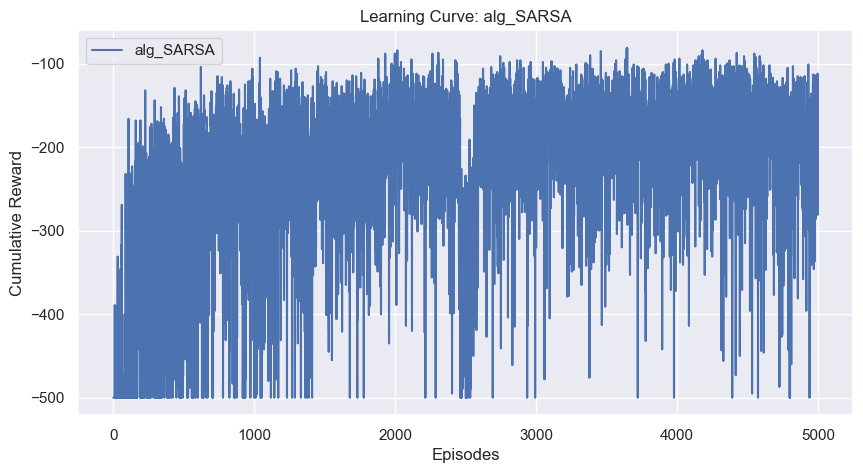

2026-04-20 21:42:06 | INFO    | Plot created in notebook.


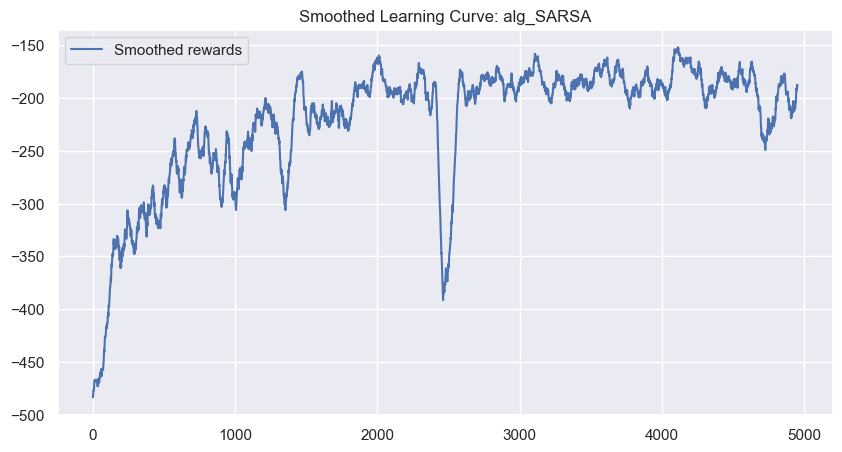

<frozen importlib._bootstrap>:241: RuntimeWarning: Your system is avx2 capable but pygame was not built with support for it. The performance of some of your blits could be adversely affected. Consider enabling compile time detection with environment variables like PYGAME_DETECT_AVX2=1 if you are compiling without cross compilation.
c:\Users\rcorr\anaconda3\envs\reinforced\Lib\site-packages\pygame\pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists



Final Summary:
{'greedy': {'mean_reward': np.float64(-156.4), 'std_reward': np.float64(43.39400880305944), 'mean_steps': np.float64(157.4), 'success_rate': np.float64(1.0)}, 'stochastic': {'mean_reward': np.float64(-320.15), 'std_reward': np.float64(123.55940878783777), 'mean_steps': np.float64(321.0), 'success_rate': np.float64(0.85)}}


In [19]:
model, rewards, evals = run_experiment(alg_SARSA, params = SARSA_PARAMS)

print("\nFinal Summary:")
print(evals)

### Hyperparameter Optimization Pipeline

#### Q-learning

In [20]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_Q.__name__}")
best_trial = param_opt_pipeline(alg_Q)

2026-04-20 21:42:21 | INFO    | Starting Optuna Hyperparameter Search: alg_Q


2026-04-20 21:42:22 | INFO    | Starting Experiment: alg_Q
2026-04-20 21:42:22 | INFO    | Hyperparameters: {'n_episodes': 5000, 'gamma': 0.99, 'show_progress': False, 'alpha': 0.3109755893002776, 'epsilon': 1.0, 'floor_fraction': 0.4177881420853835, 'epsilon_min': 0.01, 'epsilon_decay': 0.9977968891422228, 'seed': 42}
2026-04-20 21:45:25 | INFO    | alg_Q Training Completed
2026-04-20 21:45:25 | INFO    | Model checkpoint saved: models/alg_Q.pkl
2026-04-20 21:45:27 | INFO    | alg_Q Evaluation (Greedy): {'mean_reward': np.float64(-182.95), 'std_reward': np.float64(31.514242811782736), 'mean_steps': np.float64(183.95), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-182.95), 'std_reward': np.float64(31.514242811782736), 'mean_steps': np.float64(183.95), 'success_rate': np.float64(1.0)}
Stochastic: {'mean_reward': np.float64(-258.35), 'std_reward': np.float64(80.56194821378142), 'mean_steps': np.float64(259.35), 'success_rate': np.float64(1.0)}


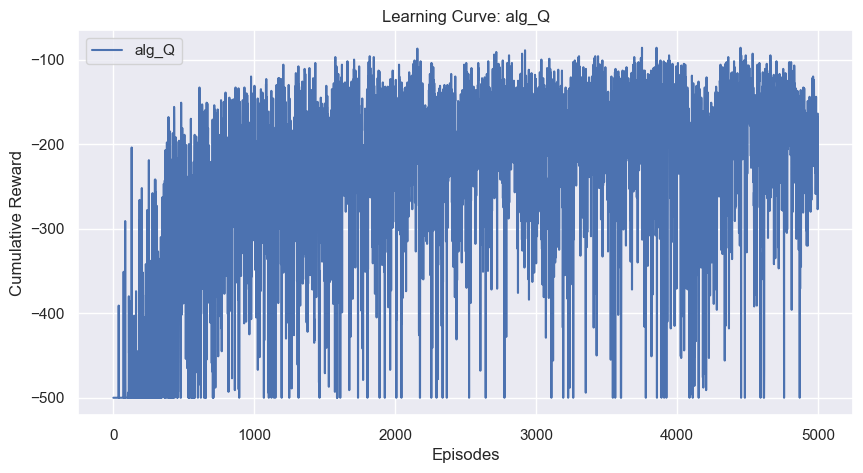

2026-04-20 21:45:27 | INFO    | Plot created in notebook.


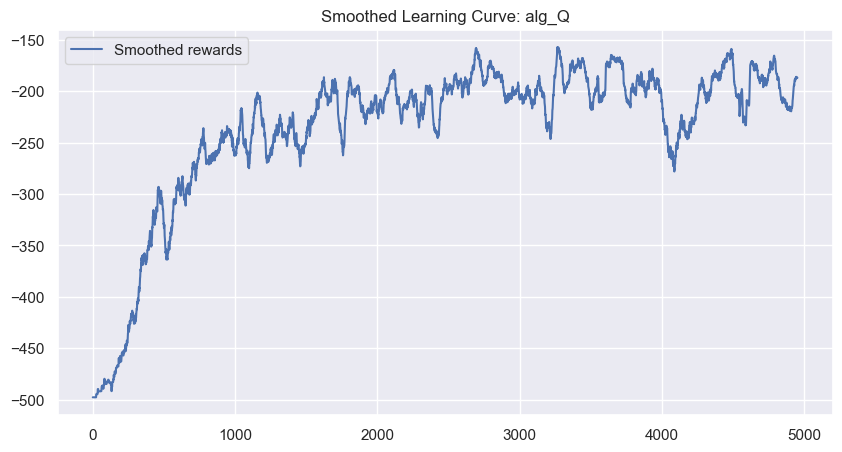


Final Summary:
{'greedy': {'mean_reward': np.float64(-182.95), 'std_reward': np.float64(31.514242811782736), 'mean_steps': np.float64(183.95), 'success_rate': np.float64(1.0)}, 'stochastic': {'mean_reward': np.float64(-258.35), 'std_reward': np.float64(80.56194821378142), 'mean_steps': np.float64(259.35), 'success_rate': np.float64(1.0)}}


In [21]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_Q")

model, rewards, evals = run_experiment(alg_Q, final_params)

print("\nFinal Summary:")
print(evals)

In [22]:
mean_q, std_q = q_stats(model)
print(f"Q mean: {mean_q:.3f}, Q std: {std_q:.3f}")

Q mean: -13.480, Q std: 10.377


In [23]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.3655555555555556)

#### n-step SARSA

In [24]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_nStep_SARSA.__name__}")
best_trial = param_opt_pipeline(alg_nStep_SARSA)

best_trial.params

2026-04-20 21:45:37 | INFO    | Starting Optuna Hyperparameter Search: alg_nStep_SARSA


{'alpha': 0.46643787494183214, 'floor_fraction': 0.634713737745095, 'n': 6}

2026-04-20 21:45:37 | INFO    | Starting Experiment: alg_nStep_SARSA
2026-04-20 21:45:37 | INFO    | Hyperparameters: {'n_episodes': 5000, 'gamma': 0.99, 'show_progress': False, 'alpha': 0.46643787494183214, 'epsilon': 1.0, 'floor_fraction': 0.634713737745095, 'epsilon_min': 0.01, 'epsilon_decay': 0.9985496911696498, 'n': 6, 'seed': 42}
2026-04-20 21:48:58 | INFO    | alg_nStep_SARSA Training Completed
2026-04-20 21:48:58 | INFO    | Model checkpoint saved: models/alg_nStep_SARSA.pkl
2026-04-20 21:48:59 | INFO    | alg_nStep_SARSA Evaluation (Greedy): {'mean_reward': np.float64(-135.2), 'std_reward': np.float64(35.38445986587897), 'mean_steps': np.float64(136.2), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-135.2), 'std_reward': np.float64(35.38445986587897), 'mean_steps': np.float64(136.2), 'success_rate': np.float64(1.0)}
Stochastic: {'mean_reward': np.float64(-155.15), 'std_reward': np.float64(41.96578963870453), 'mean_steps': np.float64(1

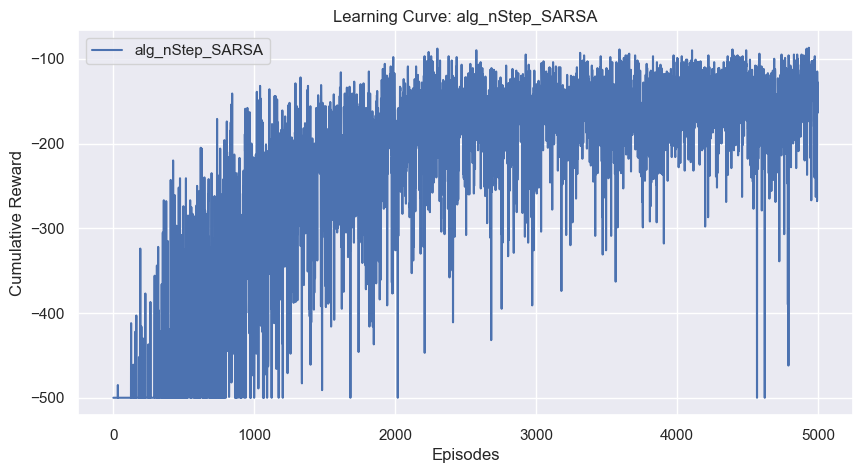

2026-04-20 21:48:59 | INFO    | Plot created in notebook.


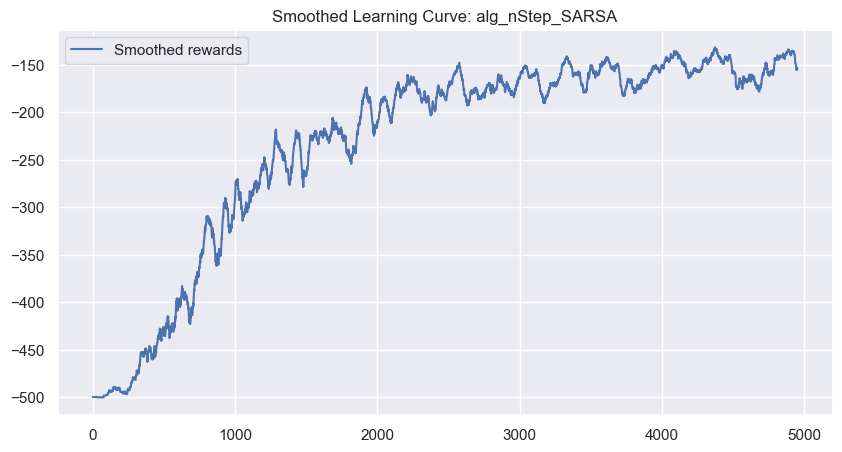


Final Summary:
{'greedy': {'mean_reward': np.float64(-135.2), 'std_reward': np.float64(35.38445986587897), 'mean_steps': np.float64(136.2), 'success_rate': np.float64(1.0)}, 'stochastic': {'mean_reward': np.float64(-155.15), 'std_reward': np.float64(41.96578963870453), 'mean_steps': np.float64(156.15), 'success_rate': np.float64(1.0)}}


In [25]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_nStep_SARSA")

model, rewards, evals = run_experiment(alg_nStep_SARSA, final_params)

print("\nFinal Summary:")
print(evals)

In [26]:
mean_q, std_q = q_stats(model)
print(f"Q mean: {mean_q:.3f}, Q std: {std_q:.3f}")

Q mean: -31.139, Q std: 20.792


In [27]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.34215277777777775)

#### REINFORCE

In [28]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_REINFORCE_B.__name__}")
best_trial = param_opt_pipeline(alg_REINFORCE_B)

best_trial.params

2026-04-20 21:49:06 | INFO    | Starting Optuna Hyperparameter Search: alg_REINFORCE_B


{'alpha_theta': 0.0036175813643992377, 'alpha_w': 0.006327186991818897}

2026-04-20 21:49:06 | INFO    | Starting Experiment: alg_REINFORCE_B
2026-04-20 21:49:06 | INFO    | Hyperparameters: {'n_episodes': 5000, 'gamma': 0.99, 'show_progress': False, 'alpha_theta': 0.0036175813643992377, 'alpha_w': 0.006327186991818897, 'seed': 42}
2026-04-20 21:55:53 | INFO    | alg_REINFORCE_B Training Completed
2026-04-20 21:55:53 | INFO    | Model checkpoint saved: models/alg_REINFORCE_B.pkl
2026-04-20 21:55:55 | INFO    | alg_REINFORCE_B Evaluation (Greedy): {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}
Stochastic: {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}


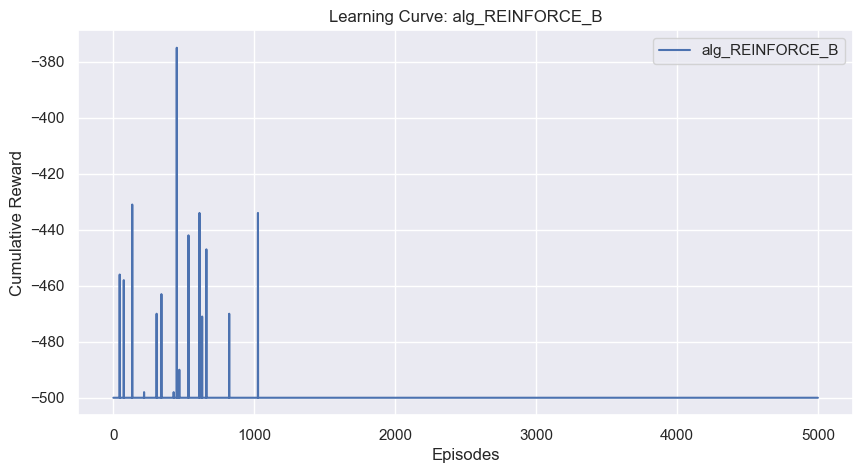

2026-04-20 21:55:56 | INFO    | Plot created in notebook.


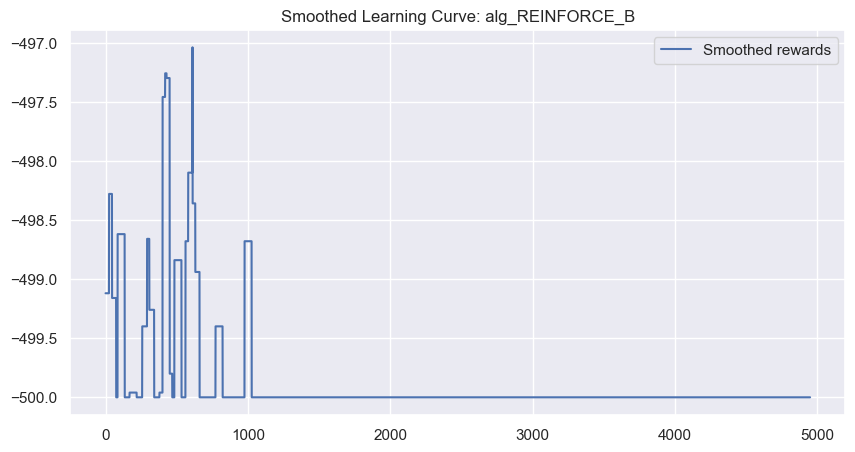


Final Summary:
{'greedy': {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}, 'stochastic': {'mean_reward': np.float64(-500.0), 'std_reward': np.float64(0.0), 'mean_steps': np.float64(500.0), 'success_rate': np.float64(0.0)}}


In [29]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_REINFORCE_B")

model, rewards, evals = run_experiment(alg_REINFORCE_B, final_params)

print("\nFinal Summary:")
print(evals)

In [30]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.15381944444444445)

#### SARSA($\lambda$)

In [31]:
main_log.info(f"Starting Optuna Hyperparameter Search: {alg_SARSA_Lambda.__name__}")
best_trial = param_opt_pipeline(alg_SARSA_Lambda)

best_trial.params

2026-04-20 21:56:17 | INFO    | Starting Optuna Hyperparameter Search: alg_SARSA_Lambda


{'alpha': 0.4113845980571551,
 'floor_fraction': 0.31124528358077885,
 'lambda': 0.9391423529971095}

2026-04-20 21:56:18 | INFO    | Starting Experiment: alg_SARSA_Lambda
2026-04-20 21:56:18 | INFO    | Hyperparameters: {'n_episodes': 5000, 'gamma': 0.99, 'show_progress': False, 'alpha': 0.4113845980571551, 'epsilon': 1.0, 'floor_fraction': 0.31124528358077885, 'epsilon_min': 0.01, 'epsilon_decay': 0.9970447544183749, 'lambda': 0.9391423529971095, 'seed': 42}
2026-04-20 22:09:00 | INFO    | alg_SARSA_Lambda Training Completed
2026-04-20 22:09:00 | INFO    | Model checkpoint saved: models/alg_SARSA_Lambda.pkl
2026-04-20 22:09:01 | INFO    | alg_SARSA_Lambda Evaluation (Greedy): {'mean_reward': np.float64(-126.05), 'std_reward': np.float64(29.21040054501136), 'mean_steps': np.float64(127.05), 'success_rate': np.float64(1.0)}

=== EVALUATION ===
Greedy: {'mean_reward': np.float64(-126.05), 'std_reward': np.float64(29.21040054501136), 'mean_steps': np.float64(127.05), 'success_rate': np.float64(1.0)}
Stochastic: {'mean_reward': np.float64(-114.95), 'std_reward': np.float64(20.958232272784

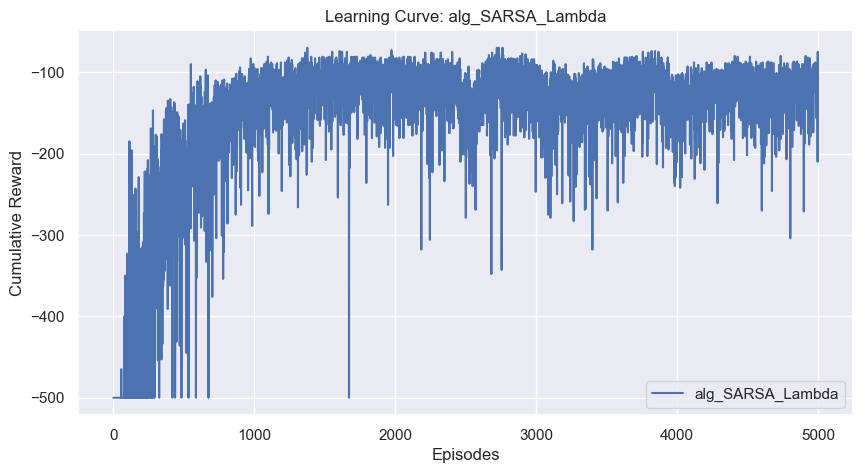

2026-04-20 22:09:02 | INFO    | Plot created in notebook.


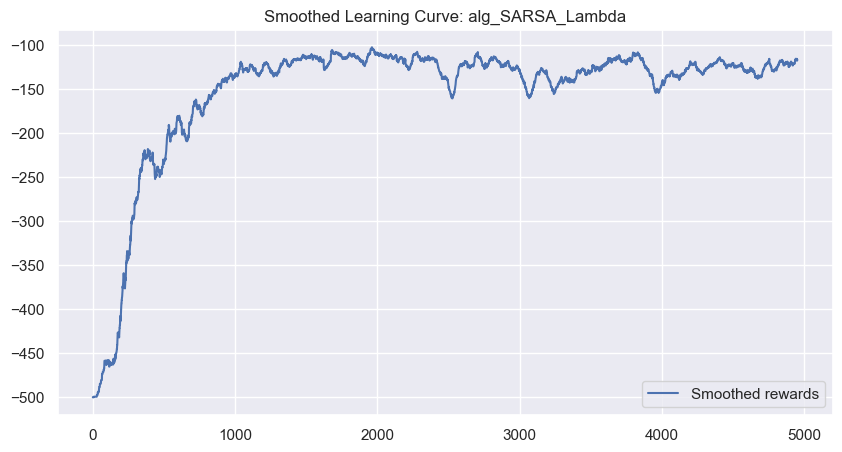


Final Summary:
{'greedy': {'mean_reward': np.float64(-126.05), 'std_reward': np.float64(29.21040054501136), 'mean_steps': np.float64(127.05), 'success_rate': np.float64(1.0)}, 'stochastic': {'mean_reward': np.float64(-114.95), 'std_reward': np.float64(20.95823227278484), 'mean_steps': np.float64(115.95), 'success_rate': np.float64(1.0)}}


In [32]:
fixed_best_trial = FixedTrial(best_trial.params)
final_params = get_params(fixed_best_trial, "alg_SARSA_Lambda")

model, rewards, evals = run_experiment(alg_SARSA_Lambda, final_params)

print("\nFinal Summary:")
print(evals)

In [33]:
mean_q, std_q = q_stats(model)
print(f"Q mean: {mean_q:.3f}, Q std: {std_q:.3f}")

Q mean: -25.415, Q std: 18.208


In [34]:
coverage = len(model.keys()) / np.prod(BINS)
coverage

np.float64(0.34555555555555556)